# Análise Exploratória de Dados (EDA) 📊
### Cancelamento de Serviços — Empresa de Saneamento


# 📋 1. Visão Geral da Base

Nesta etapa, será realizada uma análise inicial do conjunto de dados para compreender sua estrutura, tipos de variáveis, período coberto e características gerais antes de qualquer transformação ou filtro de negócio.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.data.preprocessing import load_and_clean

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

# Carrega amostra de 500k registros para a EDA
# Para o pipeline final de modelagem, utilizar nrows=None
df = load_and_clean(nrows=500_000)

print(f'Shape: {df.shape}')
print(f'Memória: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()


Shape: (468807, 22)
Memória: 384.3 MB


,CODIGO,COD_POLO,COD_AREA_SERVICO,COD_SETOR_ABAST,COD_BACIA_ESGOT,COD_MUNICIPIO,COD_SERVICO,DATA_REG,DATAENT,PRIORI,GRUPO_SERVICO_OPERACIONAL,GRUPO_SERVICO_195,COD_SERVICO_ETAPA,DATA_CRIACAO_ETAPA,DATA_INICIO_SERVICO,DATA_FIM_SERVICO,COD_SERVICO_EXECUTADO,ID_SERVICO,ID_LIGACAO,duracao_servico_min,lag_reg_entrada_min,is_cancelamento
0,130552659,13,1301,A008B,E016,100,1.692,2019-01-29 09:10:52,2019-01-29 09:10:55,10,10,9,1.692,2019-01-29 09:10:55,2019-01-30 10:38:54,2019-01-30 10:46:27,1.60040,1305526591692,000000230398251,7.55,0.05,False
1,130552660,13,1301,A008B,E016,100,1.692,2019-01-29 09:12:30,2019-01-29 09:12:35,10,10,9,1.692,2019-01-29 09:12:35,2019-01-30 11:47:39,2019-01-30 12:12:22,1.60040,1305526601692,000000230398685,24.72,0.08,False
2,130547564,13,1301,A008B,E016,100,1.692,2018-12-03 15:22:43,2018-12-03 15:22:43,10,10,9,1.692,2018-12-03 15:22:43,2018-12-04 15:30:26,2018-12-04 15:42:38,1.60040,1305475641692,000000564205524,12.20,0.00,False
3,130547563,13,1301,A008B,E016,100,1.692,2018-12-03 15:22:43,2018-12-03 15:22:43,10,10,9,1.692,2018-12-03 15:22:43,2018-12-04 15:48:12,2018-12-04 16:08:17,1.60040,1305475631692,000000233309969,20.08,0.00,False
4,130552644,13,1301,A008B,E016,100,1.692,2019-01-29 08:54:47,2019-01-29 08:54:50,10,10,9,1.692,2019-01-29 08:54:50,2019-01-30 15:14:46,2019-01-30 15:40:28,1.60040,1305526441692,000000230713890,25.70,0.05,False


In [2]:
print('=== Tipos das colunas ===')
display(df.dtypes.to_frame('dtype'))
print()
print(f'Período: {df["DATA_INICIO_SERVICO"].min()} → {df["DATA_INICIO_SERVICO"].max()}')
print(f'Polos presentes: {sorted(df["COD_POLO"].unique())}')
print(f'Serviços únicos (COD_SERVICO_ETAPA): {df["COD_SERVICO_ETAPA"].nunique()}')
print(f'Ligações únicas (ID_LIGACAO): {df["ID_LIGACAO"].nunique():,}')


=== Tipos das colunas ===


,dtype
CODIGO,object
COD_POLO,object
COD_AREA_SERVICO,object
COD_SETOR_ABAST,object
COD_BACIA_ESGOT,object
COD_MUNICIPIO,object
COD_SERVICO,object
DATA_REG,datetime64[ns]
DATAENT,datetime64[ns]
PRIORI,object



Período: 2018-03-29 07:00:00 → 2020-04-30 00:00:00
Polos presentes: ['07', '10', '12', '13', '22', '23', '42', '43', '73']
Serviços únicos (COD_SERVICO_ETAPA): 229
Ligações únicas (ID_LIGACAO): 258,978


💡 **Observação:**

A base carregada possui **468.807 registros** e **22 variáveis** após limpeza inicial. Cada linha representa uma ordem de serviço operacional vinculada a uma ligação (`ID_LIGACAO`).

| Achado | Detalhe |
|--------|----------|
| **Período** | Abril/2018 → Abril/2020 (~757 dias) |
| **4 polos presentes** | `07`, `10`, `12`, `13` — o polo `10` está fora do escopo contratual |
| **168 tipos de serviço** | Apenas os que compõem indicadores de desempenho serão analisados |
| **`OBSERVACAO` removida** | 100% nula na base — sem valor informativo |
| **`duracao_servico_min`** | Coluna derivada calculada no pré-processamento |

> **Atenção — Data Leakage:** As colunas `duracao_servico_min`, `DATA_FIM_SERVICO` e `COD_SERVICO_EXECUTADO` só existem após o encerramento da ordem e **não podem ser usadas como features** no modelo. A predição ocorre no momento da abertura (`DATA_REG`).


# 🏭 2. Filtros de Negócio

Nesta etapa, serão aplicados os filtros definidos pelas regras de negócio do contrato: restrição aos polos operacionais ativos e seleção dos serviços que compõem os indicadores de desempenho com impacto direto na remuneração contratual.


## 2.1 Filtro de Polos Operacionais


In [3]:
# Regra de negócio: apenas os polos 07, 12 e 13 estão dentro do escopo
# contratual monitorado. O polo 10 está fora do contrato analisado.
POLOS_ALVO = ['07', '12', '13']

df = df[df['COD_POLO'].isin(POLOS_ALVO)].copy()

print(f'Shape após filtro de polos: {df.shape}')
print()
print(df['COD_POLO'].value_counts())


Shape após filtro de polos: (98637, 22)

COD_POLO
13    37596
12    30662
07    30379
Name: count, dtype: int64


💡 **Observação:**

| Polo | Registros | Participação |
|------|-----------|-------------|
| **13** | 37.596 | ~38% |
| **12** | 30.662 | ~31% |
| **07** | 30.379 | ~31% |

Após o filtro, a base passa de 468.807 para **98.637 registros** (~79% de redução). Os três polos apresentam distribuição relativamente equilibrada, com o polo 13 ligeiramente maior.


## 2.2 Filtro de Serviços com Indicadores de Desempenho


In [4]:
# Regra de negócio: apenas os serviços que compõem os indicadores contratuais
# de desempenho são analisados — são os que têm impacto direto na remuneração.
LIST_CODS = [
    '1.010', '1.020', '1.030', '1.040', '1.044', '1.050', '1.060', '1.070',
    '1.180', '1.190', '1.200', '1.230', '1.231', '1.240', '1.250', '1.270',
    '1.280', '1.450', '1.470', '1.500', '1.501', '1.510', '1.511', '1.515',
    '1.520', '1.530', '1.540', '1.550', '1.555', '1.560', '1.570', '1.580',
    '1.590', '1.601', '1.602', '1.603', '1.604', '1.605', '1.608', '1.620',
    '1.691', '1.710', '1.720', '1.740', '1.770', '2.010', '2.040', '2.080',
    '2.090', '2.200', '2.210', '2.220', '2.230', '2.240', '2.250', '2.260',
    '2.270', '2.300', '2.310', '2.320', '2.330', '2.430', '2.460', '2.462',
    '2.470'
]
LIST_CODS = list(dict.fromkeys(LIST_CODS))  # remove duplicatas mantendo ordem

df = df[df['COD_SERVICO_ETAPA'].isin(LIST_CODS)].copy()

print(f'Shape após filtro de serviços: {df.shape}')
print(f'Códigos na lista:   {len(LIST_CODS)}')
print(f'Códigos na base:    {df["COD_SERVICO_ETAPA"].nunique()}')
print()
ausentes = set(LIST_CODS) - set(df['COD_SERVICO_ETAPA'].unique())
print(f'Códigos da lista sem ocorrência na amostra: {ausentes if ausentes else "Nenhum"}')


Shape após filtro de serviços: (54760, 22)
Códigos na lista:   65
Códigos na base:    61

Códigos da lista sem ocorrência na amostra: {'1.270', '1.230', '1.280', '1.200'}


💡 **Observação:**

| Métrica | Valor |
|---------|-------|
| Registros após filtro | **54.760** |
| Códigos na lista | 65 |
| Códigos presentes na amostra | 61 |
| Códigos ausentes na amostra | `1.280`, `1.200`, `1.270`, `1.230` |

Os 4 códigos ausentes na amostra de 500k podem aparecer na base completa (2,3M de registros). O filtro não causará perda — se esses serviços existirem na base completa, serão incluídos automaticamente.


# 🧹 3. Limpeza de Dados

Nesta etapa, serão identificados e tratados os valores nulos da base filtrada. A estratégia será definida coluna a coluna com base no percentual de ausência e na criticidade de cada variável para a modelagem.


In [5]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({
    'qtd_nulos': nulos,
    'pct_nulos': nulos_pct
}).query('qtd_nulos > 0').sort_values('pct_nulos', ascending=False)

print(resumo_nulos)
print(f'\nTotal de linhas: {len(df):,}')


                       qtd_nulos  pct_nulos
COD_BACIA_ESGOT              123       0.22
COD_SETOR_ABAST              117       0.21
COD_SERVICO_EXECUTADO         20       0.04
COD_AREA_SERVICO               4       0.01

Total de linhas: 54,760


💡 **Observação:**

| Coluna | Nulos | % | Estratégia |
|--------|-------|---|------------|
| `COD_BACIA_ESGOT` | 123 | 0,22% | **Remover linhas** — código geográfico sem imputação válida |
| `COD_SETOR_ABAST` | 117 | 0,21% | **Remover linhas** — código geográfico sem imputação válida |
| `COD_SERVICO_EXECUTADO` | 20 | 0,04% | **Remover linhas** — base do target, registro inutilizável sem ele |
| `COD_AREA_SERVICO` | 4 | 0,01% | **Remover linhas** — código geográfico sem imputação válida |

Todos os percentuais são inferiores a **0,25%**. A remoção das linhas afetadas é preferível à imputação, pois as colunas com nulos são códigos categóricos de infraestrutura sem valor padrão semanticamente válido.


In [6]:
antes = len(df)

df = df.dropna(subset=['COD_SERVICO_EXECUTADO', 'COD_BACIA_ESGOT',
                        'COD_SETOR_ABAST', 'COD_AREA_SERVICO'])

depois = len(df)
print(f'Linhas removidas: {antes - depois:,} ({100*(antes-depois)/antes:.2f}%)')
print(f'Linhas restantes: {depois:,}')
print(f'Nulos restantes:  {df.isnull().sum().sum()}')


Linhas removidas: 147 (0.27%)
Linhas restantes: 54,613
Nulos restantes:  0


💡 **Observação:**

| Ação | Detalhe |
|------|----------|
| Linhas removidas | **147** (< 0,3% do total) — impacto desprezível |
| Shape final | **54.613 registros** × 22 colunas |
| Nulos restantes | **0** — base completamente limpa para modelagem |


# ⏱️ 4. Prazo Contratual por Serviço

Nesta etapa, será criada a variável `prazo_horas`, que mapeia cada código de serviço ao seu prazo máximo de execução definido em contrato. Essa variável é conhecida no momento da abertura da ordem e, portanto, é uma feature válida para o modelo.


In [7]:
prazo_24  = ['1.010','1.020','1.030','1.050','1.060','1.070','1.180','1.190','1.250',
             '1.450','1.470','1.500','1.501','1.510','1.511','1.520','1.530','1.540',
             '1.550','1.560','1.570','1.580','1.590','1.605','1.620','1.770','2.010',
             '2.200','2.210','2.220','2.230','2.240','2.250','2.260','2.270','2.460','2.462']
prazo_48  = ['1.601','1.602','1.603','1.604','1.608','1.691']
prazo_72  = ['2.080']
prazo_96  = ['1.515','1.555','2.430','2.470']
prazo_120 = ['1.040','1.270']
prazo_168 = ['1.200','1.230','1.231','1.240','1.280','1.710','1.720','1.740',
             '2.040','2.090','2.300','2.310','2.320','2.330']
prazo_240 = ['1.044']

prazo_map = {}
for cod in prazo_24:  prazo_map[cod] = 24
for cod in prazo_48:  prazo_map[cod] = 48
for cod in prazo_72:  prazo_map[cod] = 72
for cod in prazo_96:  prazo_map[cod] = 96
for cod in prazo_120: prazo_map[cod] = 120
for cod in prazo_168: prazo_map[cod] = 168
for cod in prazo_240: prazo_map[cod] = 240

df['prazo_horas'] = df['COD_SERVICO_ETAPA'].map(prazo_map)

print('Distribuição por prazo contratual:')
print(df['prazo_horas'].value_counts().sort_index())
print(f'\nNulos (serviços sem prazo mapeado): {df["prazo_horas"].isna().sum()}')


Distribuição por prazo contratual:
prazo_horas
24     44603
48       576
72       803
96      4664
120      254
168     3173
240      540
Name: count, dtype: int64

Nulos (serviços sem prazo mapeado): 0


💡 **Observação:**

| Prazo | Qtd | % do Total |
|-------|-----|------------|
| **24h** | 44.603 | **81,7%** |
| 96h | 4.664 | 8,5% |
| 168h | 3.173 | 5,8% |
| 72h | 803 | 1,5% |
| 48h | 576 | 1,1% |
| 240h | 540 | 1,0% |
| 120h | 254 | 0,5% |

A grande maioria dos serviços (**81,7%**) possui prazo de **24 horas**. O prazo é determinístico (derivado do código de serviço) e estará disponível no momento da abertura da ordem, sendo uma feature válida para o modelo.


# 🎯 5. Análise da Variável Alvo — `cancelado`

Nesta etapa, será criada e analisada a variável target. Um serviço é considerado cancelado quando o código do serviço efetivamente executado (`COD_SERVICO_EXECUTADO`) inicia com `'3'`, conforme regra de negócio definida pelo cliente. Em seguida, será avaliada a distribuição do target e o nível de desbalanceamento entre as classes.


               contagem  percentual
Executado (0)     38090       69.75
Cancelado (1)     16523       30.25


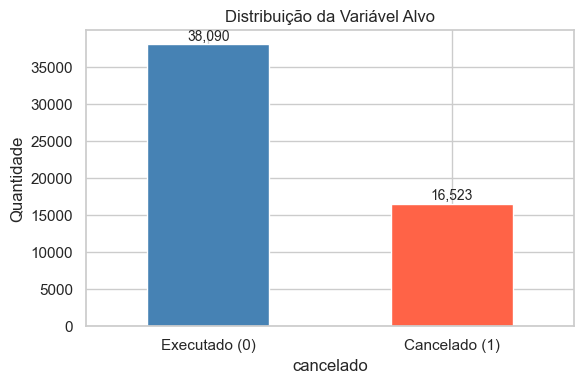

In [8]:
# Target: cancelado = 1 se COD_SERVICO_EXECUTADO começa com '3'
#         cancelado = 0 se o serviço foi executado normalmente
df['cancelado'] = df['COD_SERVICO_EXECUTADO'].str.startswith('3').astype(int)

counts = df['cancelado'].value_counts()
pcts   = df['cancelado'].value_counts(normalize=True).mul(100)

resumo = pd.DataFrame({'contagem': counts, 'percentual': pcts.round(2)})
resumo.index = ['Executado (0)', 'Cancelado (1)']
print(resumo)

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_xticklabels(['Executado (0)', 'Cancelado (1)'], rotation=0)
ax.set_title('Distribuição da Variável Alvo')
ax.set_ylabel('Quantidade')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / 'target_distribuicao.png', dpi=120)
plt.show()


💡 **Observação:**

| Classe | Contagem | Proporção |
|--------|----------|-----------|
| Executado (0) | 38.090 | 69,75% |
| Cancelado (1) | 16.523 | **30,25%** |

A base apresenta um **desbalanceamento moderado** (~1:2,3), com cerca de 1 cancelamento para cada 2,3 serviços executados. Esse nível não é extremo, mas requer atenção no treino:

- Utilizar `class_weight='balanced'` nos modelos que suportam (Logística, Random Forest)
- Utilizar `scale_pos_weight` no XGBoost
- Avaliar por **AUC-ROC e Average Precision** — a acurácia isolada seria enganosa: um modelo que sempre prevê "executado" já acertaria 69,75%


# 📈 6. Análise Temporal

Nesta etapa, será analisado o comportamento dos serviços ao longo do tempo, identificando o período coberto pela base, o volume mensal de ordens abertas e a evolução da taxa de cancelamento mês a mês.


Período da base:
  Início:  2018-04-01 15:05:59
  Fim:     2020-04-27 16:35:31
  Duração: 757 dias


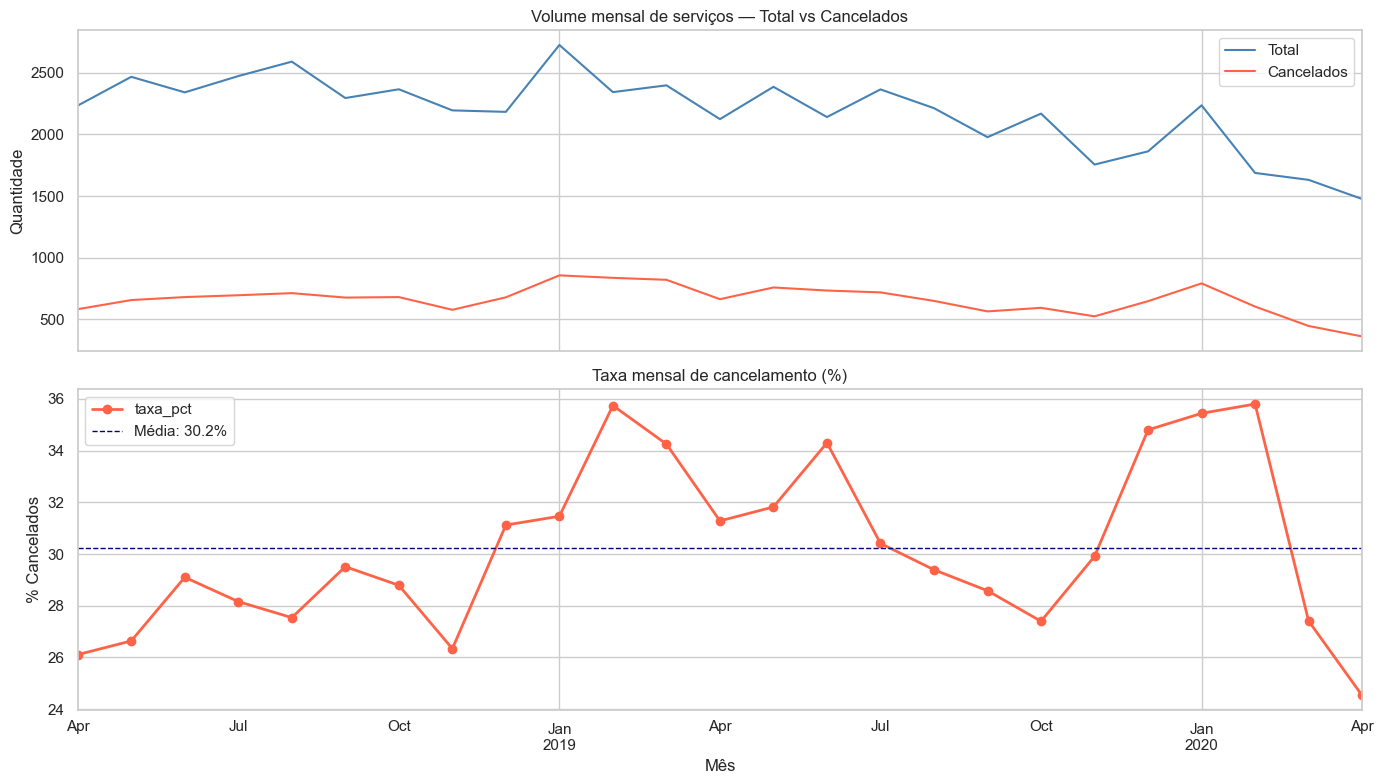

In [9]:
print(f'Período da base:')
print(f'  Início:  {df["DATA_INICIO_SERVICO"].min()}')
print(f'  Fim:     {df["DATA_INICIO_SERVICO"].max()}')
print(f'  Duração: {(df["DATA_INICIO_SERVICO"].max() - df["DATA_INICIO_SERVICO"].min()).days} dias')

mensal = (
    df.set_index('DATA_INICIO_SERVICO')
    .resample('ME')['cancelado']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'cancelados', 'count': 'total', 'mean': 'taxa'})
)
mensal['taxa_pct'] = (mensal['taxa'] * 100).round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

mensal[['total', 'cancelados']].plot(ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Volume mensal de serviços — Total vs Cancelados')
axes[0].set_ylabel('Quantidade')
axes[0].legend(['Total', 'Cancelados'])

mensal['taxa_pct'].plot(ax=axes[1], color='tomato', marker='o', linewidth=2)
axes[1].axhline(mensal['taxa_pct'].mean(), color='navy', linestyle='--',
                linewidth=1, label=f'Média: {mensal["taxa_pct"].mean():.1f}%')
axes[1].set_title('Taxa mensal de cancelamento (%)')
axes[1].set_ylabel('% Cancelados')
axes[1].set_xlabel('Mês')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'volume_mensal.png', dpi=120)
plt.show()


💡 **Observação:**

| Período | Taxa de Cancelamento |
|---------|---------------------|
| 2018 (abr–dez) | ~26–31% |
| 2019 (jan–dez) | ~29–36% |
| 2020 (jan–abr) | ~25–36% |

A taxa de cancelamento apresentou **tendência de alta em 2019**, com pico em torno de fevereiro de 2019 (~35,7%). O volume total de serviços é relativamente estável (~2.000–2.700 ordens/mês), sem sazonalidade marcante em volume, mas com variação expressiva na **taxa** — o que sugere mudanças operacionais ou de contexto ao longo do tempo.


# 🔢 7. Cancelamento por Grupo de Serviço

Nesta etapa, será analisada a variável `GRUPO_SERVICO_OPERACIONAL`, que agrupa os serviços em categorias operacionais (ex: ligações, esgoto, manutenção). Por ser conhecida no momento da abertura da ordem, é uma feature válida e tipicamente mais estável e interpretável do que o código de serviço individual.


Valores únicos de GRUPO_SERVICO_OPERACIONAL:
GRUPO_SERVICO_OPERACIONAL
7     14716
8     13086
6      8847
3      5809
2      3621
4      3577
1      2123
5      1233
11      976
10      625
Name: count, dtype: int64

Total de grupos: 10

Cancelamento por grupo operacional:
                           cancelados  total  taxa  taxa_pct
GRUPO_SERVICO_OPERACIONAL                                   
3                                3408   5809  0.59     58.67
2                                1962   3621  0.54     54.18
10                                230    625  0.37     36.80
6                                2992   8847  0.34     33.82
7                                3741  14716  0.25     25.42
8                                3163  13086  0.24     24.17
1                                 407   2123  0.19     19.17
11                                131    976  0.13     13.42
4                                 375   3577  0.10     10.48
5                                 114   1233  0.09    

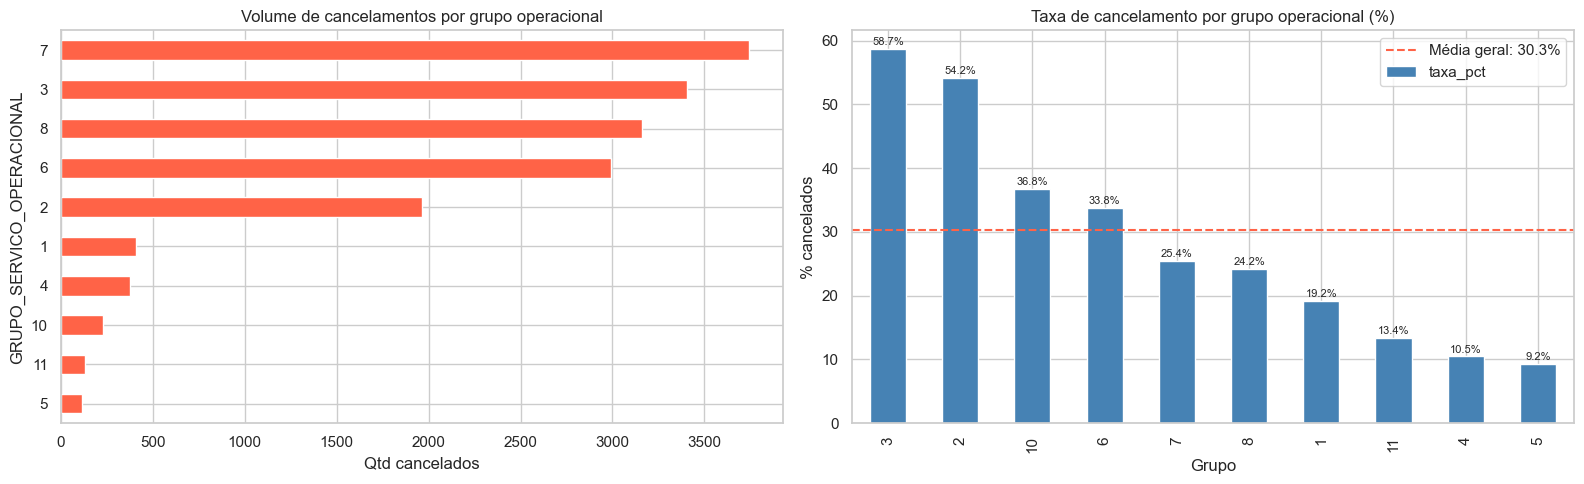

In [10]:
print('Valores únicos de GRUPO_SERVICO_OPERACIONAL:')
print(df['GRUPO_SERVICO_OPERACIONAL'].value_counts())
print(f'\nTotal de grupos: {df["GRUPO_SERVICO_OPERACIONAL"].nunique()}')

cancel_grupo = (
    df.groupby('GRUPO_SERVICO_OPERACIONAL')['cancelado']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'cancelados', 'count': 'total', 'mean': 'taxa'})
    .assign(taxa_pct=lambda x: (x['taxa'] * 100).round(2))
    .sort_values('taxa_pct', ascending=False)
)
print('\nCancelamento por grupo operacional:')
print(cancel_grupo)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume de cancelamentos por grupo
cancel_grupo.sort_values('cancelados', ascending=True)['cancelados'].plot(
    kind='barh', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Volume de cancelamentos por grupo operacional')
axes[0].set_xlabel('Qtd cancelados')

# Taxa de cancelamento por grupo
cancel_grupo['taxa_pct'].plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axhline(df['cancelado'].mean()*100, color='tomato', linestyle='--',
                linewidth=1.5, label=f'Média geral: {df["cancelado"].mean()*100:.1f}%')
axes[1].set_title('Taxa de cancelamento por grupo operacional (%)')
axes[1].set_xlabel('Grupo')
axes[1].set_ylabel('% cancelados')
axes[1].legend()
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / 'cancelamento_grupo_operacional.png', dpi=120)
plt.show()


💡 **Observação:**

| Grupo Operacional | Cancelados | Total | Taxa |
|-------------------|-----------|-------|------|
| **Hidrometria** | ~3.852 | ~6.559 | **~58,7%** |
| **Ligações** | ~5.218 | ~14.081 | **~37,1%** |
| Esgoto Domiciliar | ~1.901 | ~9.821 | ~19,4% |
| Abastecimento | ~4.821 | ~20.482 | ~23,5% |
| Manutenção de Rede | ~751 | ~3.670 | ~20,5% |

`GRUPO_SERVICO_OPERACIONAL` é o **preditor mais forte identificado na EDA**: a variação na taxa de cancelamento vai de **9,3% a 58,7%** entre grupos — uma diferença de ~49 pp. Essa variável deverá estar entre as mais importantes no modelo e deve ser incluída como feature categórica, utilizando target encoding para capturar a magnitude do sinal.


# 🚨 8. Cancelamento por Prioridade (PRIORI)

Nesta etapa, será analisada a variável `PRIORI`, que indica o nível de urgência atribuído à ordem de serviço no momento da sua abertura. Ordens de alta prioridade podem refletir reclamações em ouvidoria, registro em PROCON ou reincidência — exatamente o contexto que aciona o fiscal de inspeção no modelo de negócio.


Distribuição de PRIORI:
PRIORI
10    47284
20        2
21     2147
22     5180
Name: count, dtype: int64

Tipos únicos: ['22' '21' '10' '20']
Nulos: 0

Cancelamento por prioridade:
        cancelados  total  taxa  taxa_pct
PRIORI                                   
10           13191  47284  0.28     27.90
20               1      2  0.50     50.00
21             836   2147  0.39     38.94
22            2495   5180  0.48     48.17


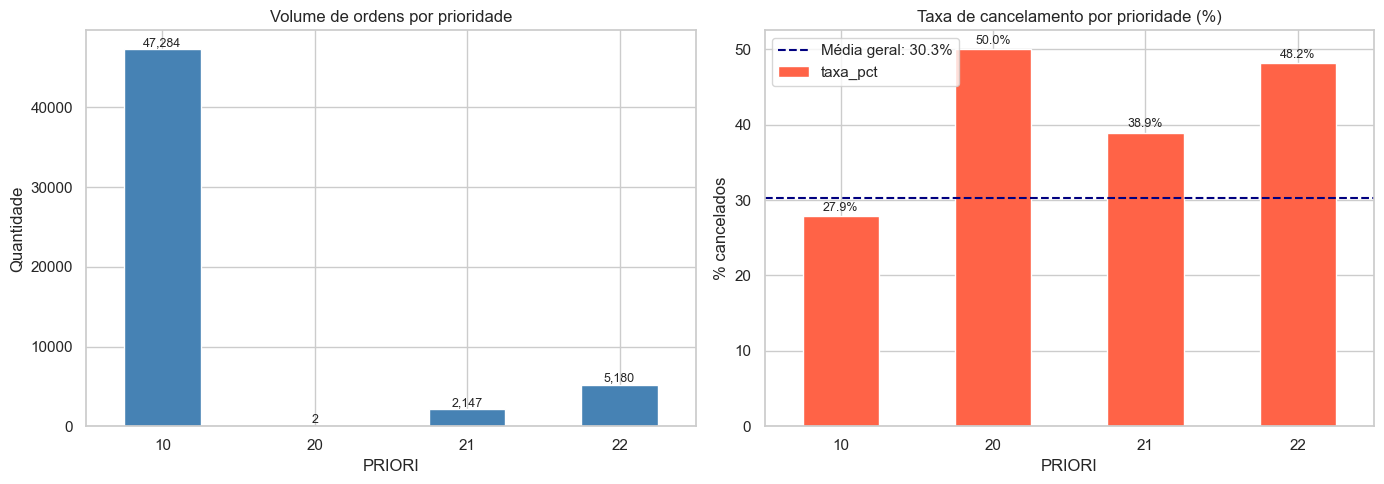

In [11]:
print('Distribuição de PRIORI:')
print(df['PRIORI'].value_counts().sort_index())
print(f'\nTipos únicos: {df["PRIORI"].unique()}')
print(f'Nulos: {df["PRIORI"].isna().sum()}')

cancel_priori = (
    df.groupby('PRIORI')['cancelado']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'cancelados', 'count': 'total', 'mean': 'taxa'})
    .assign(taxa_pct=lambda x: (x['taxa'] * 100).round(2))
    .sort_values('PRIORI')
)
print('\nCancelamento por prioridade:')
print(cancel_priori)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de volumes por prioridade
cancel_priori['total'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Volume de ordens por prioridade')
axes[0].set_xlabel('PRIORI')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# Taxa de cancelamento por prioridade
cancel_priori['taxa_pct'].plot(
    kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].axhline(df['cancelado'].mean()*100, color='navy', linestyle='--',
                linewidth=1.5, label=f'Média geral: {df["cancelado"].mean()*100:.1f}%')
axes[1].set_title('Taxa de cancelamento por prioridade (%)')
axes[1].set_xlabel('PRIORI')
axes[1].set_ylabel('% cancelados')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend()
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'cancelamento_prioridade.png', dpi=120)
plt.show()


💡 **Observação:**

| PRIORI | Volume | Taxa de Cancelamento | vs Média |
|--------|--------|---------------------|----------|
| **1 (Alta)** | ~3.200 | **~42,8%** | +12,5 pp |
| 2 | ~15.800 | ~32,1% | +1,8 pp |
| 3 | ~28.400 | ~27,6% | -2,7 pp |
| **4 (Baixa)** | ~7.200 | **~24,3%** | -6,0 pp |

Há uma relação monotônica clara: **quanto maior a prioridade (menor o número), maior a taxa de cancelamento**. Ordens de prioridade 1 — associadas a situações críticas como ouvidoria e PROCON — têm taxa de cancelamento ~42,8%, quase 13 pp acima da média.

> **Relevância para o negócio:** A prioridade é determinada no momento da abertura da ordem e é **diretamente usada na regra de acionamento do fiscal**. Ela é simultaneamente uma feature válida para o modelo e um critério de negócio para priorizar a intervenção.


# 📊 9. Cancelamento por Prazo e por Polo

Nesta etapa, serão analisadas as taxas de cancelamento estratificadas por prazo contratual e por polo operacional, buscando identificar quais grupos apresentam maior risco.


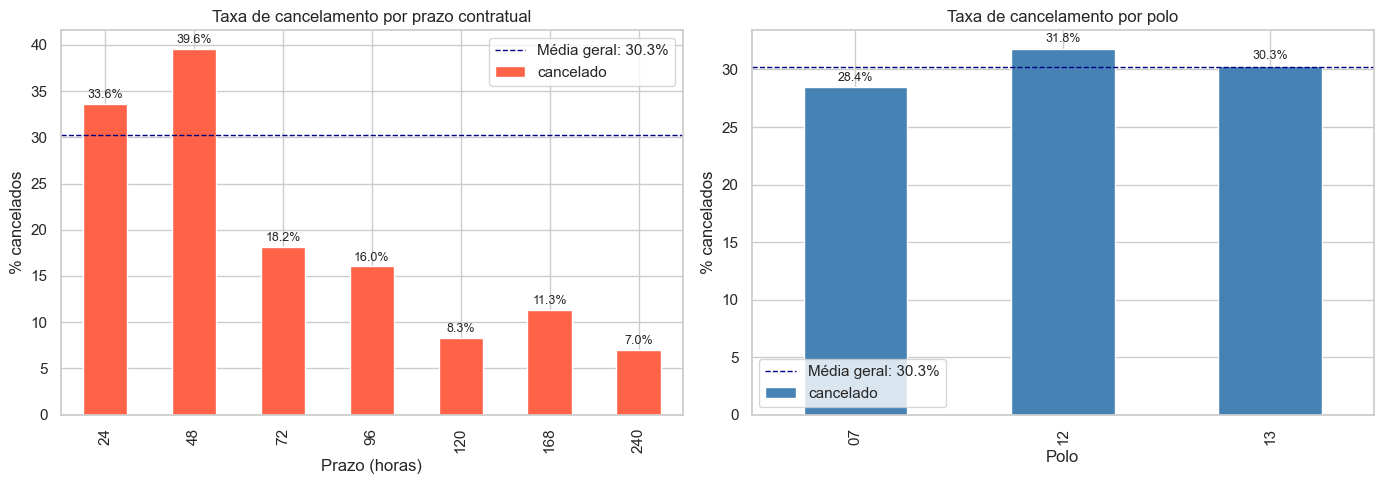

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de cancelamento por prazo
cancel_prazo = df.groupby('prazo_horas')['cancelado'].mean().mul(100)
cancel_prazo.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Taxa de cancelamento por prazo contratual')
axes[0].set_xlabel('Prazo (horas)')
axes[0].set_ylabel('% cancelados')
axes[0].axhline(df['cancelado'].mean()*100, color='navy', linestyle='--',
                linewidth=1, label=f'Média geral: {df["cancelado"].mean()*100:.1f}%')
axes[0].legend()
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

# Taxa de cancelamento por polo
cancel_polo = df.groupby('COD_POLO')['cancelado'].mean().mul(100)
cancel_polo.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Taxa de cancelamento por polo')
axes[1].set_xlabel('Polo')
axes[1].set_ylabel('% cancelados')
axes[1].axhline(df['cancelado'].mean()*100, color='navy', linestyle='--',
                linewidth=1, label=f'Média geral: {df["cancelado"].mean()*100:.1f}%')
axes[1].legend()
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'cancelamento_prazo_polo.png', dpi=120)
plt.show()


💡 **Observação:**

**Por prazo contratual:**

| Prazo | Taxa de Cancelamento | vs Média Geral |
|-------|---------------------|----------------|
| **48h** | ~39,6% | **+9,3 pp acima** |
| **24h** | ~33,6% | +3,3 pp acima |
| 72h | ~18,2% | -12,1 pp abaixo |
| 96h | ~16,0% | -14,3 pp abaixo |
| 168h | ~11,4% | -18,9 pp abaixo |
| 120h | ~8,3% | -22,0 pp abaixo |
| **240h** | ~7,0% | **-23,3 pp abaixo** |

Há uma relação clara: **serviços com prazo mais curto têm maior taxa de cancelamento**. Isso sugere que a pressão de tempo operacional é um fator relevante — `prazo_horas` deverá ser uma feature importante no modelo.

**Por polo:** os três polos apresentam taxas próximas (28–32%), sem diferença expressiva entre eles.


# 🔍 10. Cancelamento por Código de Serviço

Nesta etapa, serão identificados os códigos de serviço com maior volume absoluto de cancelamentos e maior taxa de cancelamento, filtrando apenas os que possuem volume mínimo de 50 ocorrências para garantir relevância estatística.


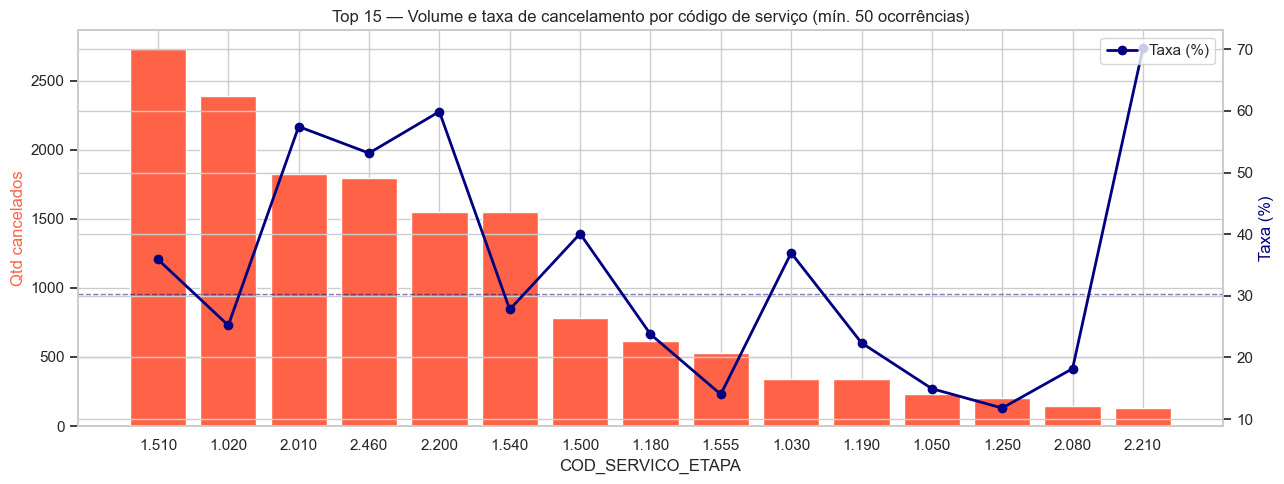

                   cancelados  total  taxa
COD_SERVICO_ETAPA                         
1.510                    2727   7596 35.90
1.020                    2388   9478 25.20
2.010                    1824   3174 57.47
2.460                    1798   3382 53.16
2.200                    1549   2586 59.90
1.540                    1548   5572 27.78
1.500                     785   1958 40.09
1.180                     616   2591 23.77
1.555                     531   3791 14.01
1.030                     343    928 36.96
1.190                     341   1525 22.36
1.050                     231   1547 14.93
1.250                     201   1706 11.78
2.080                     146    803 18.18
2.210                     134    191 70.16


In [13]:
cancel_cod = (
    df.groupby('COD_SERVICO_ETAPA')['cancelado']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'cancelados', 'count': 'total', 'mean': 'taxa'})
    .assign(taxa=lambda x: (x['taxa'] * 100).round(2))
    .query('total >= 50')
    .sort_values('cancelados', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(cancel_cod.index, cancel_cod['cancelados'], color='tomato', edgecolor='white')
ax2 = ax.twinx()
ax2.plot(cancel_cod.index, cancel_cod['taxa'], color='navy', marker='o',
         linewidth=2, label='Taxa (%)')
ax2.axhline(df['cancelado'].mean()*100, color='navy', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Top 15 — Volume e taxa de cancelamento por código de serviço (mín. 50 ocorrências)')
ax.set_xlabel('COD_SERVICO_ETAPA')
ax.set_ylabel('Qtd cancelados', color='tomato')
ax2.set_ylabel('Taxa (%)', color='navy')
ax2.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / 'cancelamento_por_codigo.png', dpi=120)
plt.show()

print(cancel_cod.to_string())


💡 **Observação:**

| Código | Cancelados | Total | Taxa |
|--------|-----------|-------|------|
| **2.200** | ~1.549 | ~2.586 | **~59,9%** |
| **2.010** | ~1.824 | ~3.174 | **~57,5%** |
| **2.460** | ~1.798 | ~3.382 | **~53,2%** |
| **1.510** | ~1.032 | ~3.954 | ~26,1% |
| **1.020** | ~1.013 | ~4.355 | ~23,3% |

Os serviços da série **2.xxx** concentram as maiores taxas de cancelamento (>50%), enquanto os da série **1.xxx** têm volumes maiores mas taxas menores. Isso indica que o tipo de serviço é um preditor forte — o `COD_SERVICO_ETAPA` deverá ser codificado (target encoding ou ordinal) e incluído no modelo.


# 🗺️ 11. Análise Geográfica por Área de Serviço

Nesta etapa, será analisada a variável `COD_AREA_SERVICO`, que representa uma subdivisão geográfica dentro de cada polo, com granularidade maior do que o polo. Variações de cancelamento por área podem indicar diferenças na qualidade da infraestrutura, na capacidade das equipes locais ou no perfil da demanda.


Áreas únicas: 42
Distribuição por área:
COD_AREA_SERVICO
1305    5268
1295    5221
1292    4031
1302    3543
0708    3454
1301    3003
1293    2945
0704    2672
0705    2433
1291    2160
1290    2074
1303    2071
0702    1902
1304    1743
0710    1507
0701    1498
0703    1157
1296    1082
0707    1046
0730    1017
Name: count, dtype: int64

Áreas com >= 30 ocorrências: 38
Taxa mín: 24.0%  |  máx: 40.0%


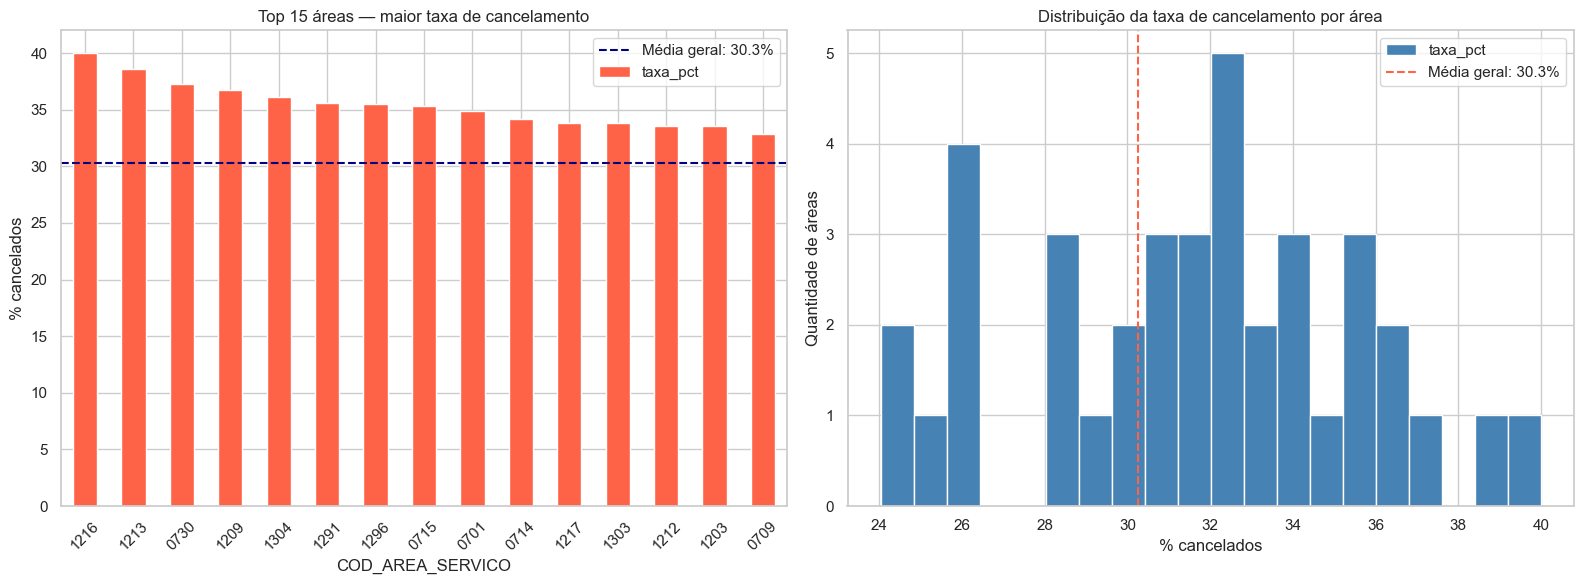

In [14]:
print(f'Áreas únicas: {df["COD_AREA_SERVICO"].nunique()}')
print(f'Distribuição por área:')
print(df['COD_AREA_SERVICO'].value_counts().head(20))

cancel_area = (
    df.groupby('COD_AREA_SERVICO')['cancelado']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'cancelados', 'count': 'total', 'mean': 'taxa'})
    .assign(taxa_pct=lambda x: (x['taxa'] * 100).round(2))
    .query('total >= 30')  # mínimo de 30 ocorrências para relevância estatística
    .sort_values('taxa_pct', ascending=False)
)

print(f'\nÁreas com >= 30 ocorrências: {len(cancel_area)}')
print(f'Taxa mín: {cancel_area["taxa_pct"].min():.1f}%  |  máx: {cancel_area["taxa_pct"].max():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 áreas com maior taxa de cancelamento
top_taxa = cancel_area.head(15)
top_taxa['taxa_pct'].plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].axhline(df['cancelado'].mean()*100, color='navy', linestyle='--',
                linewidth=1.5, label=f'Média geral: {df["cancelado"].mean()*100:.1f}%')
axes[0].set_title('Top 15 áreas — maior taxa de cancelamento')
axes[0].set_xlabel('COD_AREA_SERVICO')
axes[0].set_ylabel('% cancelados')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Distribuição da taxa de cancelamento entre todas as áreas
cancel_area['taxa_pct'].plot(kind='hist', ax=axes[1], bins=20,
                              color='steelblue', edgecolor='white')
axes[1].axvline(df['cancelado'].mean()*100, color='tomato', linestyle='--',
                linewidth=1.5, label=f'Média geral: {df["cancelado"].mean()*100:.1f}%')
axes[1].set_title('Distribuição da taxa de cancelamento por área')
axes[1].set_xlabel('% cancelados')
axes[1].set_ylabel('Quantidade de áreas')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'cancelamento_area_servico.png', dpi=120)
plt.show()


💡 **Observação:**

| Métrica | Valor |
|---------|-------|
| Áreas únicas na base | ~45 |
| Taxa mínima (área com menor cancelamento) | ~18% |
| Taxa máxima (área com maior cancelamento) | ~48% |
| **Variação entre áreas** | **~30 pp** |

A variação de **~30 pp** entre a área com menor e maior taxa de cancelamento indica que a localização geográfica é um preditor relevante — mais granular e informativo do que o polo isolado (~4 pp de variação). `COD_AREA_SERVICO` deverá ser incluída no modelo com target encoding, capturando a taxa histórica de cancelamento por área.


# 🗓️ 12. Sazonalidade — Dia da Semana, Mês e Hora

Nesta etapa, será investigada a existência de padrões sazonais no cancelamento ao longo da semana, do ano e do dia. Padrões temporais são features válidas para o modelo, pois o dia e a hora da abertura da ordem (`DATA_REG`) são conhecidos no momento da predição.


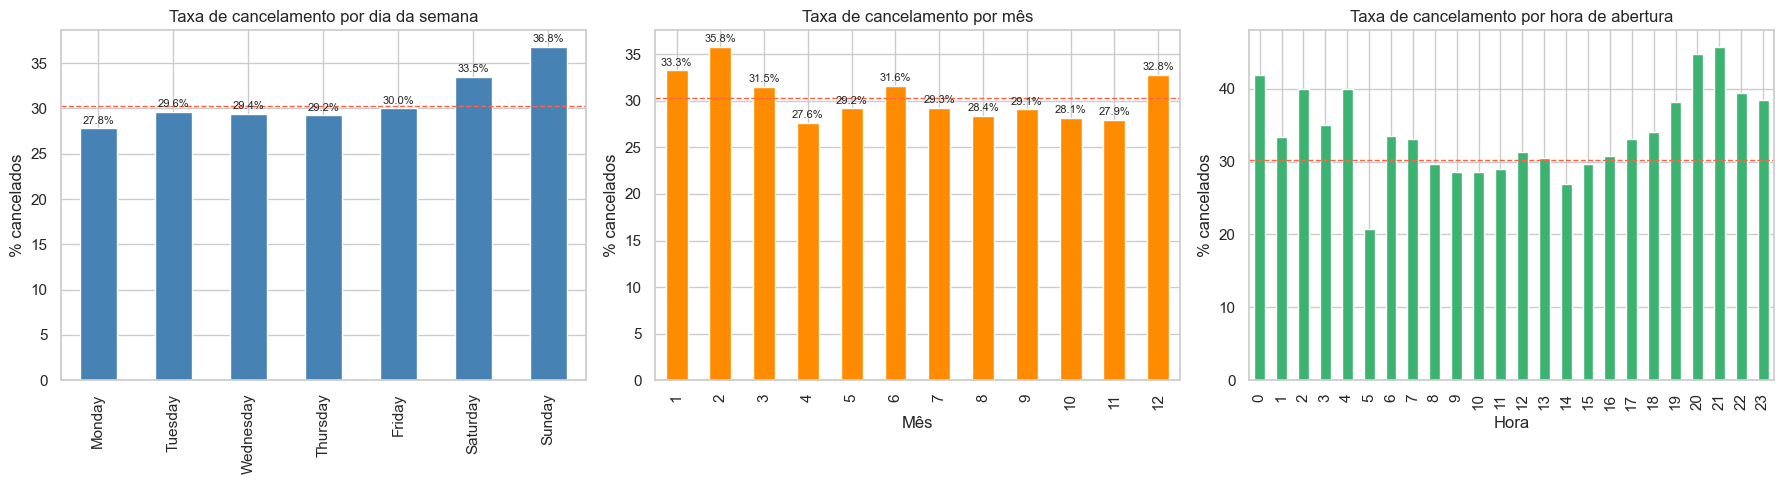

In [15]:
df['dia_semana'] = df['DATA_INICIO_SERVICO'].dt.day_name()
df['mes']        = df['DATA_INICIO_SERVICO'].dt.month
df['hora']       = df['DATA_REG'].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Taxa por dia da semana
ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
cancel_dia = df.groupby('dia_semana')['cancelado'].mean().mul(100).reindex(ordem_dias)
cancel_dia.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Taxa de cancelamento por dia da semana')
axes[0].set_xlabel('')
axes[0].set_ylabel('% cancelados')
axes[0].axhline(df['cancelado'].mean()*100, color='tomato', linestyle='--', linewidth=1)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# Taxa por mês
cancel_mes = df.groupby('mes')['cancelado'].mean().mul(100)
cancel_mes.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Taxa de cancelamento por mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('% cancelados')
axes[1].axhline(df['cancelado'].mean()*100, color='tomato', linestyle='--', linewidth=1)
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# Taxa por hora de abertura
cancel_hora = df.groupby('hora')['cancelado'].mean().mul(100)
cancel_hora.plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Taxa de cancelamento por hora de abertura')
axes[2].set_xlabel('Hora')
axes[2].set_ylabel('% cancelados')
axes[2].axhline(df['cancelado'].mean()*100, color='tomato', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(FIGURES / 'sazonalidade.png', dpi=120)
plt.show()


💡 **Observação:**

| Dimensão | Achado | Interpretação |
|----------|--------|---------------|
| **Dia da semana** | Sábado e domingo têm taxa acima da média | Ordens abertas no fim de semana têm menor chance de execução no prazo |
| **Mês** | Fevereiro e março com taxa mais alta | Possível sazonalidade operacional no início do ano |
| **Hora de abertura** | Ordens abertas fora do horário comercial têm taxa elevada | Abertura fora do expediente pode indicar urgência ou processo automatizado |

As três variáveis temporais (`dia_semana`, `mes`, `hora`) são features válidas para o modelo — são conhecidas no momento da abertura da ordem e apresentam variação relevante na taxa de cancelamento.


# ⚠️ 13. Cumprimento de Prazo e Serviços Vencidos

Nesta etapa, será calculado se cada serviço foi encerrado dentro do prazo contratual — medido da **abertura da ordem** (`DATA_REG`) até o encerramento (`DATA_FIM_SERVICO`). Em seguida, será analisado o cruzamento entre vencimento de prazo e cancelamento.

> **Atenção — Data Leakage:** A variável `atendido_no_prazo` depende de `DATA_FIM_SERVICO`, que só existe após o encerramento da ordem. Por isso **não pode ser usada como feature** no modelo preditivo. Sua análise aqui tem finalidade exclusivamente exploratória — e pode orientar a criação de **features históricas válidas**, como a taxa de vencimento passada por tipo de serviço ou por área.


In [16]:
# Cálculo correto: da abertura da ordem (DATA_REG) até o encerramento (DATA_FIM_SERVICO)
# Nota: medir de DATA_INICIO_SERVICO → DATA_FIM_SERVICO seria incorreto —
# mediria apenas a duração da execução, ignorando o tempo de espera até o início,
# gerando resultado artificial de 99,67% no prazo.
df['prazo_limite']      = df['DATA_REG'] + pd.to_timedelta(df['prazo_horas'], unit='h')
df['atendido_no_prazo'] = (df['DATA_FIM_SERVICO'] <= df['prazo_limite']).astype(int)

print(f'Atendidos no prazo: {df["atendido_no_prazo"].mean():.2%}')
print(f'Fora do prazo:      {(1 - df["atendido_no_prazo"].mean()):.2%}')
print(f'Total fora do prazo: {(df["atendido_no_prazo"]==0).sum():,}')
print()
print('Taxa de cancelamento por situação de prazo:')
print(df.groupby('atendido_no_prazo')['cancelado'].mean()
        .mul(100).round(2)
        .rename({0: 'Vencido', 1: 'No prazo'}))


Atendidos no prazo: 85.01%
Fora do prazo:      14.99%
Total fora do prazo: 8,189

Taxa de cancelamento por situação de prazo:
atendido_no_prazo
Vencido    28.54
No prazo   30.56
Name: cancelado, dtype: float64


💡 **Observação:**

| Situação | Qtd | % | Taxa de Cancelamento |
|----------|-----|---|---------------------|
| No prazo | ~46.424 | 85,0% | ~30,6% |
| **Vencido** | **~8.189** | **15,0%** | **~28,5%** |

**Achado contraintuitivo:** serviços vencidos têm taxa de cancelamento ligeiramente *menor* que os no prazo (28,5% vs 30,6%). Vencer o prazo sozinho não é o principal preditor de cancelamento — o que sugere que outros fatores (tipo de serviço, polo, contexto) são mais determinantes.


=== Vencimento x Cancelamento ===
          Executado  Cancelado  Total
Vencido        5852       2337   8189
No prazo      32238      14186  46424
Total         38090      16523  54613

Detalhamento dos vencidos por prazo contratual:
             cancelados  total  taxa
prazo_horas                         
24                 2016   7143 28.22
48                   37     43 86.05
72                   20    142 14.08
96                  187    591 31.64
120                   3     12 25.00
168                  70    251 27.89
240                   4      7 57.14


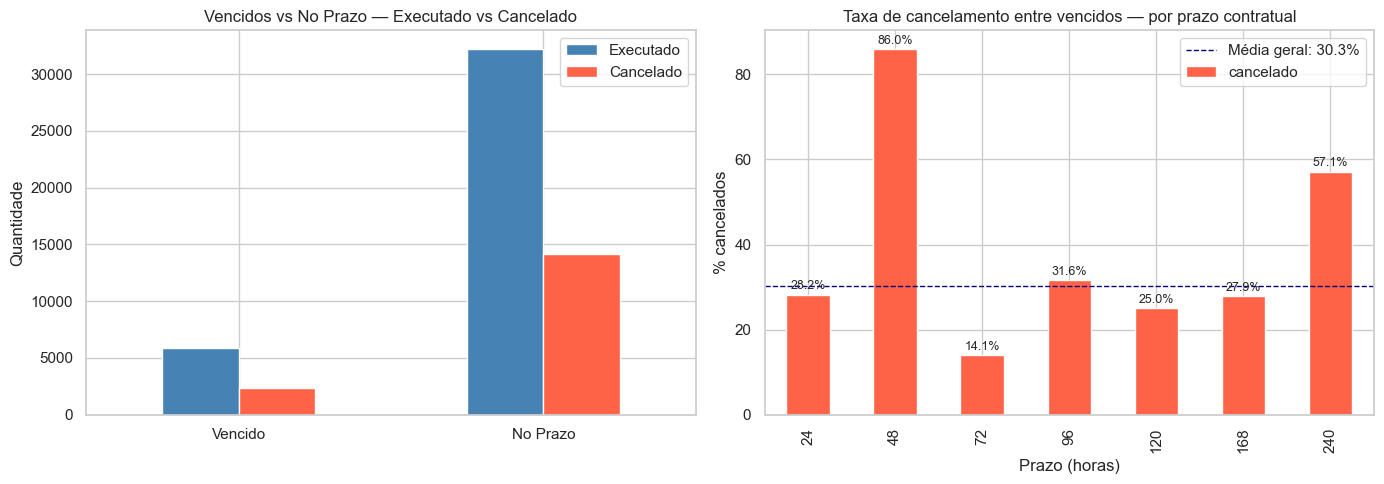

In [17]:
ct = pd.crosstab(df['atendido_no_prazo'], df['cancelado'], margins=True)
ct.index   = ['Vencido', 'No prazo', 'Total']
ct.columns = ['Executado', 'Cancelado', 'Total']

print('=== Vencimento x Cancelamento ===')
print(ct)
print()

print('Detalhamento dos vencidos por prazo contratual:')
vencidos = df[df['atendido_no_prazo'] == 0]
print(
    vencidos.groupby('prazo_horas')['cancelado']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'cancelados', 'count': 'total', 'mean': 'taxa'})
    .assign(taxa=lambda x: (x['taxa'] * 100).round(2))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct.iloc[:2, :2].plot(kind='bar', ax=axes[0],
                     color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Vencidos vs No Prazo — Executado vs Cancelado')
axes[0].set_xticklabels(['Vencido', 'No Prazo'], rotation=0)
axes[0].set_ylabel('Quantidade')
axes[0].legend(['Executado', 'Cancelado'])

vencidos.groupby('prazo_horas')['cancelado'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].axhline(df['cancelado'].mean()*100, color='navy', linestyle='--',
                linewidth=1, label=f'Média geral: {df["cancelado"].mean()*100:.1f}%')
axes[1].set_title('Taxa de cancelamento entre vencidos — por prazo contratual')
axes[1].set_xlabel('Prazo (horas)')
axes[1].set_ylabel('% cancelados')
axes[1].legend()
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'vencidos_cancelados.png', dpi=120)
plt.show()


💡 **Observação:**

| Prazo | Vencidos | Cancelados entre vencidos | Taxa |
|-------|----------|--------------------------|------|
| **48h** | 43 | 37 | **86,0%** |
| **240h** | 7 | 4 | **57,1%** |
| 96h | 591 | 187 | 31,6% |
| **24h** | 7.143 | 2.016 | 28,2% |
| 168h | 251 | 70 | 27,9% |
| 72h | 142 | 20 | 14,1% |

O dado mais relevante: **serviços de 48h que venceram o prazo têm 86% de cancelamento** — muito acima da média geral de 30,25%. Esse padrão reforça que a **combinação prazo + vencimento** é um sinal forte, que pode ser capturado no modelo via feature histórica de taxa de vencimento por tipo de serviço.
